In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Precipitaciones/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,1,VAEXJOE,SE,+56:52:00,+014:48:00,166
1,2,FALUN,SE,+60:37:00,+015:37:00,160
2,3,STENSELE,SE,+65:04:00,+017:09:59,325
3,4,LINKOEPING,SE,+58:24:00,+015:31:59,93
4,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
...,...,...,...,...,...,...
17116,27903,VALSTAGNA,IT,+45:51:45,+011:39:33,148
17117,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
17118,27939,TRONDHEIM - GRANASEN,NO,+63:22:32,+010:18:45,186
17119,27940,BARKALD,NO,+61:59:30,+010:53:11,452


In [3]:
#Filtrado de datos para España
metadata_ESP=metadata[metadata.CN=='ES']
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
205,229,BADAJOZ AEROPUERTO,ES,+38:52:59,-006:48:50,186
207,231,MALAGA AEROPUERTO,ES,+36:39:57,-004:28:55,7
208,232,PUERTO DE NAVACERRADA,ES,+40:47:35,-004:00:38,1893
209,233,SALAMANCA AEROPUERTO,ES,+40:57:33,-005:29:53,790
211,235,TORREVIEJA,ES,+37:58:37,-000:42:38,1
...,...,...,...,...,...,...
16911,27679,MIRANDA DE EBRO,ES,+42:24:41,+002:34:24,460
16912,27683,VALDEZCARAY,ES,+42:09:06,+002:34:49,1630
16913,27684,MEDINA DE POMAR,ES,+42:33:03,+003:17:08,580
16916,27696,BRIVIESCA,ES,+42:19:59,+003:10:59,730


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_ESP['LAT'] = metadata_ESP['LAT'].apply(dms_a_decimal)
metadata_ESP['LON'] = metadata_ESP['LON'].apply(dms_a_decimal)
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
205,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
207,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
208,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
209,233,SALAMANCA AEROPUERTO,ES,40.959167,-5.498056,790
211,235,TORREVIEJA,ES,37.976944,-0.710556,1
...,...,...,...,...,...,...
16911,27679,MIRANDA DE EBRO,ES,42.411389,2.573333,460
16912,27683,VALDEZCARAY,ES,42.151667,2.580278,1630
16913,27684,MEDINA DE POMAR,ES,42.550833,3.285556,580
16916,27696,BRIVIESCA,ES,42.333056,3.183056,730


In [6]:
#Carga de mapas para obtener mapa de España
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
spain = world[world["name"] == "Spain"] #Mapa de España

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_ESP['LON'], metadata_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_ESP, geometry=estaciones, crs="EPSG:4326") 

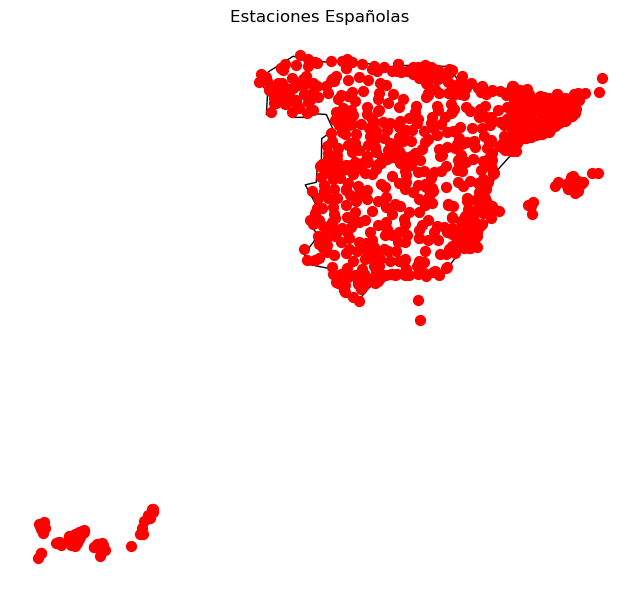

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones españolas
lista_estaciones_espanolas=metadata_ESP.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='RR_STAID000000'
station_i=station[:-len(str(lista_estaciones_espanolas[0]))]+str(lista_estaciones_espanolas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Precipitaciones/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
data_unif=data.loc[:,['DATE','RR']]
data_unif.set_index('DATE', inplace=True)
data_unif

,RR
DATE,
2008-01-01,156
2008-01-02,138
2008-01-03,66
2008-01-04,0
2008-01-05,5
...,...
2025-03-25,0
2025-03-26,0
2025-03-27,0


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_espanolas[1:]:
    station='RR_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Precipitaciones/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
    df=data.loc[:,['DATE','RR']]
    df.set_index('DATE', inplace=True)
    data_unif['RR '+str(i)]=df

data_unif

,RR,RR 231,RR 232,RR 233,RR 235,RR 236,RR 237,RR 309,RR 336,RR 337,...,RR 27664,RR 27665,RR 27667,RR 27670,RR 27672,RR 27679,RR 27683,RR 27684,RR 27696,RR 27700
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,156,0,8.0,10.0,0.0,0.0,0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,12.0,0.0,NaN,NaN,NaN,NaN
2008-01-02,138,21,132.0,93.0,30.0,47.0,65,20.0,52.0,389.0,...,NaN,NaN,NaN,NaN,16.0,10.0,NaN,NaN,NaN,NaN
2008-01-03,66,69,65.0,11.0,30.0,10.0,8,1.0,13.0,50.0,...,NaN,NaN,NaN,NaN,0.0,16.0,NaN,NaN,NaN,NaN
2008-01-04,0,0,15.0,0.0,0.0,0.0,0,0.0,0.0,50.0,...,NaN,NaN,NaN,NaN,0.0,2.0,NaN,NaN,NaN,NaN
2008-01-05,5,0,192.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0,21,0.0,0.0,NaN,0.0,2,1.0,48.0,0.0,...,7.0,7.0,20.0,60.0,6.0,2.0,72.0,6.0,4.0,32.0
2025-03-26,0,0,0.0,0.0,NaN,0.0,0,0.0,0.0,0.0,...,3.0,1.0,0.0,0.0,4.0,0.0,12.0,4.0,0.0,0.0
2025-03-27,0,0,0.0,0.0,NaN,0.0,0,0.0,NaN,0.0,...,0.0,0.0,0.0,0.0,10.0,0.0,8.0,0.0,0.0,0.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen datos faltantes y se renombra la primera estación con el IDs de estación
d=data_unif.dropna(axis=1)
d=d.rename({'RR':'RR 229'},axis=1)
d

,RR 229,RR 231,RR 237,RR 11014,RR 11082,RR 11085,RR 26989,RR 27422,RR 27423,RR 27436,RR 27610
DATE,,,,,,,,,,,
2008-01-01,156,0,0,0,0,0,0,0,0,0,0
2008-01-02,138,21,65,39,60,8,8,61,108,26,60
2008-01-03,66,69,8,95,44,245,245,90,118,130,44
2008-01-04,0,0,0,0,0,1,1,0,0,0,0
2008-01-05,5,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0,21,2,0,0,8,8,8,10,0,0
2025-03-26,0,0,0,12,0,12,12,0,0,0,0
2025-03-27,0,0,0,0,0,4,4,0,0,0,0


In [13]:
# Lista de estaciones españolas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_ESP[metadata_ESP.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
205,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
207,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
213,237,VALENCIA,ES,39.480556,-0.366389,11
6740,11014,BARCELONA-EL RAVAL,ES,41.383889,2.167500,33
6808,11082,ULLDEMOLINS,ES,41.320000,0.885556,687
6811,11085,VILADRAU,ES,41.840000,2.418333,953
16258,26989,FOGARS DE MONTCLUS,ES,41.760000,2.430833,936
16687,27422,MALAGA,ES,36.716667,-4.419444,25
16688,27423,RINCON DE LA VICTORIA,ES,36.715000,-4.285833,7
16700,27436,EL EJIDO,ES,36.774444,-2.813056,98


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

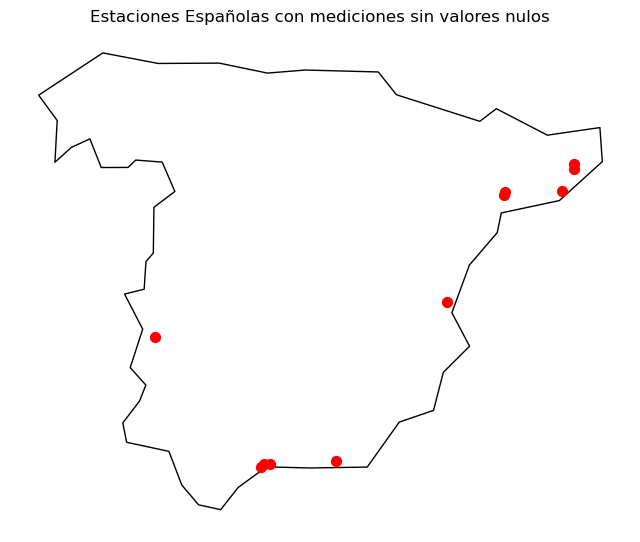

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_esp=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_esp['LON'],mt_esp['LAT'],mt_esp['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_ESP=mt_esp[mt_esp.STAID.isin(ww)]
mt_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
205,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
207,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
213,237,VALENCIA,ES,39.480556,-0.366389,11
6740,11014,BARCELONA-EL RAVAL,ES,41.383889,2.167500,33
6808,11082,ULLDEMOLINS,ES,41.320000,0.885556,687
16700,27436,EL EJIDO,ES,36.774444,-2.813056,98


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_ESP['LON'], mt_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(mt_ESP, geometry=estaciones, crs="EPSG:4326") 

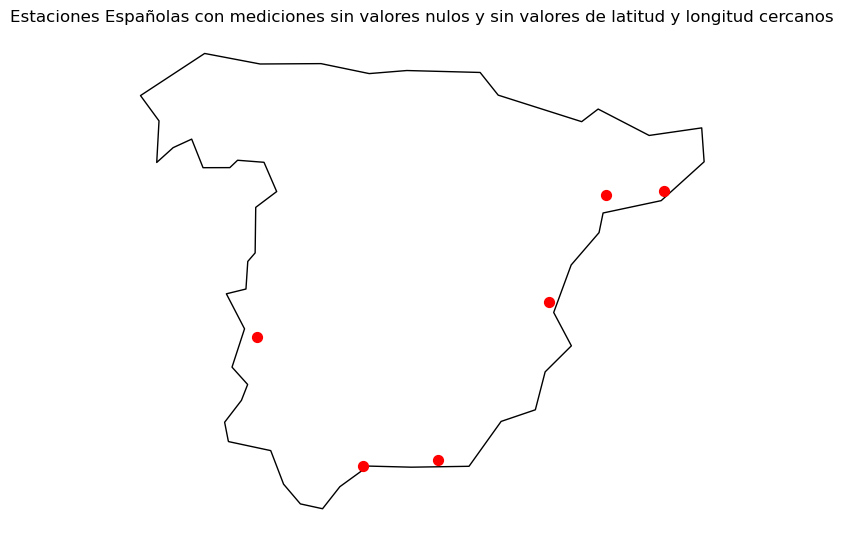

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos mensuales para cada estación
data=d.loc[:,['RR '+str(i) for i in mt_ESP.STAID.to_list()]]
data=data.resample('MS').mean()
data

,RR 229,RR 231,RR 237,RR 11014,RR 11082,RR 27436
DATE,,,,,,
2008-01-01,16.580645,9.225806,2.709677,5.354839,7.290323,6.645161
2008-02-01,29.379310,9.586207,16.931034,11.724138,6.827586,9.172414
2008-03-01,2.838710,7.129032,2.032258,6.870968,3.548387,0.129032
2008-04-01,28.033333,15.800000,2.600000,10.366667,22.500000,2.266667
2008-05-01,18.903226,2.741935,46.193548,30.161290,64.548387,27.612903
...,...,...,...,...,...,...
2024-11-01,12.068966,25.379310,9.413793,15.241379,25.448276,0.896552
2024-12-01,2.600000,18.333333,7.900000,11.266667,4.000000,0.533333
2025-01-01,31.333333,9.766667,7.266667,2.266667,1.600000,0.400000


In [21]:
#Cálculo de la media para cada mes en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'RR'},axis=1)
a

,RR
DATE,
2008-01-01,7.967742
2008-02-01,13.936782
2008-03-01,3.758065
2008-04-01,13.594444
2008-05-01,31.693548
...,...
2024-11-01,14.741379
2024-12-01,7.438889
2025-01-01,8.772222


In [22]:
#Exportación de datos mensuales de las precipitaciones en España
a.to_csv('precipitaciones_mensuales_esp.csv',index=True,encoding='utf-8')

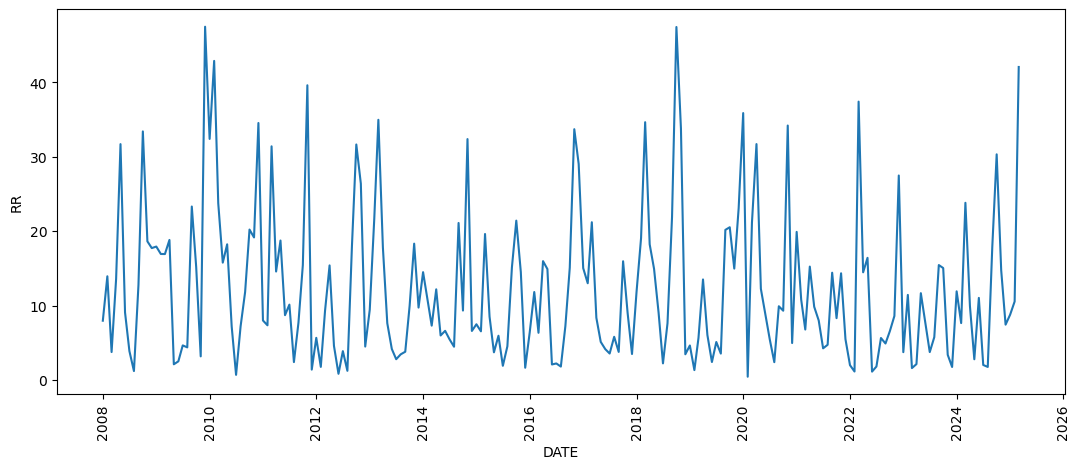

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.RR)
plt.xticks(rotation=90)
plt.show()